In [147]:
import pandas as pd
import matplotlib.pyplot as plt

Прочитайте файл `2017_jun_final.csv` за допомогою методу `read_csv`.

In [122]:
reader = pd.read_csv('datasets/2017_jun_final.csv', chunksize=10000)
df = pd.concat(reader, ignore_index=True)
df.set_index('N', inplace=True)

Прочитайте отриману таблицю, використовуючи метод `head`.

In [123]:
df.head()

,Посада,Мова програмування,Спеціалізація,Загальний досвід роботи,Досвід роботи на поточному місці,Зарплата на місяць,Зміна зарплати за 12 місяців,Місто,Розмір компанії,Тип компанії,...,Ще студент,Рівень англійської,Предметна область,Дата заповнення,User.Agent,exp,current_job_exp,salary,Валюта,cls
N,,,,,,,,,,,,,,,,,,,,,
1,Junior QA engineer,NaN,Manual QA,0.5,0.5,400,0,Харків,до 10 осіб,Аутсорсингова,...,True,Pre-intermediate (нище середнього),"iOS,eCommerce",12/06/2017 12:38:08,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,0.5,0.5,400,NaN,QA
2,Junior QA engineer,NaN,Manual QA,менше 3 місяців,менше 3 місяців,430,130,Харків,більше 1000 осіб,Аутсорсингова,...,True,Upper-Intermediate (вище середнього),Веб-розробка,12/06/2017 12:42:51,Mozilla/5.0 (iPad; CPU OS 10_2_1 like Mac OS X...,0.0,0.0,430,NaN,QA
3,Software Engineer,C#/.NET,NaN,4,1,2500,800,Київ,до 1000 осіб,Аутсорсингова,...,False,Intermediate (середній),"Веб-розробка,Корпоративні системи",12/06/2017 13:02:47,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,4.0,1.0,2500,NaN,DEV
4,Software Engineer,JavaScript,NaN,5,4,2000,400,Одеса,до 200 осіб,Продуктова,...,False,Pre-intermediate (нище середнього),"Desktop Applications,Веб-розробка",12/06/2017 13:03:01,Mozilla/5.0 (Windows NT 6.1; Win64; x64) Apple...,5.0,4.0,2000,NaN,DEV
5,Senior Software Engineer,JavaScript,NaN,10 і більше років,0.5,4500,500,Інше,до 10 осіб,Продуктова,...,False,Intermediate (середній),"Desktop Applications,Веб-розробка",12/06/2017 13:03:47,Mozilla/5.0 (iPhone; CPU iPhone OS 10_3_2 like...,10.0,0.5,4500,NaN,DEV


Визначте розмір таблиці за допомогою методу `shape`.

In [124]:
df.shape

(8704, 24)

Визначте типи всіх стовпців за допомогою `dataframe.dtypes`.

In [125]:
df.dtypes

Посада                                  str
Мова програмування                      str
Спеціалізація                           str
Загальний досвід роботи                 str
Досвід роботи на поточному місці        str
Зарплата на місяць                    int64
Зміна зарплати за 12 місяців          int64
Місто                                   str
Розмір компанії                         str
Тип компанії                            str
Стать                                   str
Вік                                   int64
Освіта                                  str
Університет                             str
Ще студент                             bool
Рівень англійської                      str
Предметна область                       str
Дата заповнення                         str
User.Agent                              str
exp                                 float64
current_job_exp                     float64
salary                                int64
Валюта                          

Порахуйте, яка частка пропусків міститься в кожній колонці, використовуючи методи `isnull` та `sum`.

In [126]:
ratio = df.isnull().sum().sort_values(ascending=False) / df.shape[0]
ratio.rename('ratio')

Валюта                              0.998851
Спеціалізація                       0.829389
Мова програмування                  0.442325
cls                                 0.180836
Університет                         0.041131
Предметна область                   0.025620
salary                              0.000000
current_job_exp                     0.000000
exp                                 0.000000
User.Agent                          0.000000
Дата заповнення                     0.000000
Рівень англійської                  0.000000
Ще студент                          0.000000
Посада                              0.000000
Вік                                 0.000000
Стать                               0.000000
Тип компанії                        0.000000
Розмір компанії                     0.000000
Місто                               0.000000
Зміна зарплати за 12 місяців        0.000000
Зарплата на місяць                  0.000000
Досвід роботи на поточному місці    0.000000
Загальний 

Видаліть усі стовпці з пропусками, крім стовпця `"Мова програмування"`.

In [127]:
to_delete = ratio.drop(['Мова програмування'])[ratio > 0.0]
to_delete_index = df.columns.intersection(to_delete.index)
df.drop(columns=to_delete_index, inplace=True)
df

,Посада,Мова програмування,Загальний досвід роботи,Досвід роботи на поточному місці,Зарплата на місяць,Зміна зарплати за 12 місяців,Місто,Розмір компанії,Тип компанії,Стать,Вік,Освіта,Ще студент,Рівень англійської,Дата заповнення,User.Agent,exp,current_job_exp,salary
N,,,,,,,,,,,,,,,,,,,
1,Junior QA engineer,NaN,0.5,0.5,400,0,Харків,до 10 осіб,Аутсорсингова,жіноча,20,Неповна Вища,True,Pre-intermediate (нище середнього),12/06/2017 12:38:08,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,0.5,0.5,400
2,Junior QA engineer,NaN,менше 3 місяців,менше 3 місяців,430,130,Харків,більше 1000 осіб,Аутсорсингова,жіноча,21,Неповна Вища,True,Upper-Intermediate (вище середнього),12/06/2017 12:42:51,Mozilla/5.0 (iPad; CPU OS 10_2_1 like Mac OS X...,0.0,0.0,430
3,Software Engineer,C#/.NET,4,1,2500,800,Київ,до 1000 осіб,Аутсорсингова,чоловіча,26,Вища,False,Intermediate (середній),12/06/2017 13:02:47,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,4.0,1.0,2500
4,Software Engineer,JavaScript,5,4,2000,400,Одеса,до 200 осіб,Продуктова,чоловіча,30,Середня,False,Pre-intermediate (нище середнього),12/06/2017 13:03:01,Mozilla/5.0 (Windows NT 6.1; Win64; x64) Apple...,5.0,4.0,2000
5,Senior Software Engineer,JavaScript,10 і більше років,0.5,4500,500,Інше,до 10 осіб,Продуктова,чоловіча,30,Технікум / Коледж,False,Intermediate (середній),12/06/2017 13:03:47,Mozilla/5.0 (iPhone; CPU iPhone OS 10_3_2 like...,10.0,0.5,4500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8700,QA engineer,NaN,1,менше 3 місяців,700,700,Одеса,до 50 осіб,Аутсорсингова,чоловіча,23,Вища,False,Intermediate (середній),12/07/2017 15:45:24,Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:54....,1.0,0.0,700
8701,Marketing,NaN,0.5,0.5,400,120,Київ,до 50 осіб,Продуктова,жіноча,22,Вища,False,Pre-intermediate (нище середнього),12/07/2017 17:00:06,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,0.5,0.5,400
8702,Junior Software Engineer,Ruby/Rails,1,0.5,800,500,Львів,до 10 осіб,Аутстафінгова,чоловіча,30,Неповна Вища,False,Upper-Intermediate (вище середнього),12/07/2017 17:32:26,Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/53...,1.0,0.5,800


Знову порахуйте, яка частка пропусків міститься в кожній колонці, і переконайтеся, що залишився тільки стовпець `"Мова програмування"`.

In [128]:
ratio = df.isnull().sum().sort_values(ascending=False) / df.shape[0]
ratio.rename('ratio')

Мова програмування                  0.442325
Посада                              0.000000
Вік                                 0.000000
current_job_exp                     0.000000
exp                                 0.000000
User.Agent                          0.000000
Дата заповнення                     0.000000
Рівень англійської                  0.000000
Ще студент                          0.000000
Освіта                              0.000000
Стать                               0.000000
Тип компанії                        0.000000
Розмір компанії                     0.000000
Місто                               0.000000
Зміна зарплати за 12 місяців        0.000000
Зарплата на місяць                  0.000000
Досвід роботи на поточному місці    0.000000
Загальний досвід роботи             0.000000
salary                              0.000000
Name: ratio, dtype: float64

Видаліть усі рядки у вихідній таблиці за допомогою методу `dropna`.

In [129]:
df.dropna(inplace=True)
df

,Посада,Мова програмування,Загальний досвід роботи,Досвід роботи на поточному місці,Зарплата на місяць,Зміна зарплати за 12 місяців,Місто,Розмір компанії,Тип компанії,Стать,Вік,Освіта,Ще студент,Рівень англійської,Дата заповнення,User.Agent,exp,current_job_exp,salary
N,,,,,,,,,,,,,,,,,,,
3,Software Engineer,C#/.NET,4,1,2500,800,Київ,до 1000 осіб,Аутсорсингова,чоловіча,26,Вища,False,Intermediate (середній),12/06/2017 13:02:47,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,4.0,1.0,2500
4,Software Engineer,JavaScript,5,4,2000,400,Одеса,до 200 осіб,Продуктова,чоловіча,30,Середня,False,Pre-intermediate (нище середнього),12/06/2017 13:03:01,Mozilla/5.0 (Windows NT 6.1; Win64; x64) Apple...,5.0,4.0,2000
5,Senior Software Engineer,JavaScript,10 і більше років,0.5,4500,500,Інше,до 10 осіб,Продуктова,чоловіча,30,Технікум / Коледж,False,Intermediate (середній),12/06/2017 13:03:47,Mozilla/5.0 (iPhone; CPU iPhone OS 10_3_2 like...,10.0,0.5,4500
7,Junior Software Engineer,C#/.NET,1,менше 3 місяців,600,100,Хмельницький,до 50 осіб,Аутсорсингова,чоловіча,23,Вища,False,Pre-intermediate (нище середнього),12/06/2017 13:04:26,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1.0,0.0,600
8,Senior Software Engineer,C++,6,1,3300,500,Київ,до 10 осіб,Продуктова,чоловіча,28,Вища,False,Upper-Intermediate (вище середнього),12/06/2017 13:04:27,Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:53....,6.0,1.0,3300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8693,Software Engineer,Java,5,1,3500,650,Віддалено,до 200 осіб,Аутсорсингова,жіноча,28,Вища,False,Intermediate (середній),12/07/2017 13:26:49,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_12_5...,5.0,1.0,3500
8695,Junior Software Engineer,C#/.NET,1,1,550,550,Харків,до 200 осіб,Аутсорсингова,чоловіча,23,Вища,False,Pre-intermediate (нище середнього),12/07/2017 14:14:33,Mozilla/5.0 (Windows NT 10.0; WOW64; rv:54.0) ...,1.0,1.0,550
8696,Software Engineer,Python,1,0.5,1500,1000,Київ,до 10 осіб,Стартап,чоловіча,29,Вища,False,Intermediate (середній),12/07/2017 14:39:21,Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/53...,1.0,0.5,1500


Визначте новий розмір таблиці за допомогою методу `shape`.

In [130]:
df.shape

(4854, 19)

Створіть нову таблицю `python_data`, в якій будуть тільки рядки зі спеціалістами, які вказали мову програмування Python.

In [131]:
python_data = df[df['Мова програмування'] == 'Python']
python_data

,Посада,Мова програмування,Загальний досвід роботи,Досвід роботи на поточному місці,Зарплата на місяць,Зміна зарплати за 12 місяців,Місто,Розмір компанії,Тип компанії,Стать,Вік,Освіта,Ще студент,Рівень англійської,Дата заповнення,User.Agent,exp,current_job_exp,salary
N,,,,,,,,,,,,,,,,,,,
13,Software Engineer,Python,1,менше 3 місяців,800,200,Київ,до 50 осіб,Аутсорсингова,чоловіча,26,Вища,False,Pre-intermediate (нище середнього),12/06/2017 13:05:54,Mozilla/5.0 (Windows NT 6.1; Win64; x64) Apple...,1.0,0.0,800
69,Software Engineer,Python,1.5,0.5,900,900,Київ,до 10 осіб,Стартап,чоловіча,21,Неповна Вища,True,Upper-Intermediate (вище середнього),12/06/2017 13:11:17,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1.5,0.5,900
88,Junior Software Engineer,Python,0.5,0.5,600,0,Київ,до 10 осіб,Аутсорсингова,чоловіча,19,Неповна Вища,True,Upper-Intermediate (вище середнього),12/06/2017 13:12:25,Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/53...,0.5,0.5,600
115,Junior Software Engineer,Python,1.5,0.5,685,250,Київ,до 1000 осіб,Аутсорсингова,чоловіча,21,Неповна Вища,False,Intermediate (середній),12/06/2017 13:14:52,Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/53...,1.5,0.5,685
144,Junior Software Engineer,Python,1,1,750,250,Київ,до 10 осіб,Аутсорсингова,чоловіча,21,Неповна Вища,True,Upper-Intermediate (вище середнього),12/06/2017 13:19:10,Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/53...,1.0,1.0,750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8547,Software Engineer,Python,5,1,2000,800,Запоріжжя,до 50 осіб,Аутсорсингова,чоловіча,22,Неповна Вища,False,Intermediate (середній),10/07/2017 14:11:26,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_12_5...,5.0,1.0,2000
8626,Software Engineer,Python,4,1,1750,0,Київ,більше 1000 осіб,Аутсорсингова,чоловіча,28,Середня,False,Intermediate (середній),11/07/2017 16:15:40,Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:54....,4.0,1.0,1750
8636,Senior Software Engineer,Python,10 і більше років,менше 3 місяців,4000,1300,Віддалено,до 10 осіб,Стартап,чоловіча,33,Вища,False,Upper-Intermediate (вище середнього),11/07/2017 17:51:36,Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/53...,10.0,0.0,4000


Визначте розмір таблиці `python_data` за допомогою методу `shape`.

In [132]:
python_data.shape

(207, 19)

Використовуючи метод `groupby`, виконайте групування за стовпчиком `"Посада"`.

In [133]:
python_data_grouped = python_data.groupby('Посада')

Створіть новий DataFrame, де для згрупованих даних за стовпчиком `"Посада"` виконайте агрегацію даних за допомогою методу `agg` і знайдіть мінімальне та максимальне значення у стовпчику `"Зарплата.в.місяць"`.

In [134]:
python_salary_by_position = python_data_grouped.agg(
    min_salary=('Зарплата на місяць', 'min'),
    max_salary=('Зарплата на місяць', 'max'),
)
python_salary_by_position

,min_salary,max_salary
Посада,,
Junior Software Engineer,100,1250
Senior Software Engineer,1300,9200
Software Engineer,500,5400
System Architect,3000,5000
Technical Lead,1425,6200


Створіть функцію `fill_avg_salary`, яка повертатиме середнє значення заробітної плати на місяць. Використайте її для методу `apply` та створіть новий стовпчик `"avg"`.

In [138]:
def fill_avg_salary(row):
    return (row['min_salary'] + row['max_salary']) / 2

python_salary_by_position['avg'] = python_salary_by_position.apply(fill_avg_salary, axis=1)
python_salary_by_position

,min_salary,max_salary,avg
Посада,,,
Junior Software Engineer,100,1250,675.0
Senior Software Engineer,1300,9200,5250.0
Software Engineer,500,5400,2950.0
System Architect,3000,5000,4000.0
Technical Lead,1425,6200,3812.5


<Axes: ylabel='Посада'>

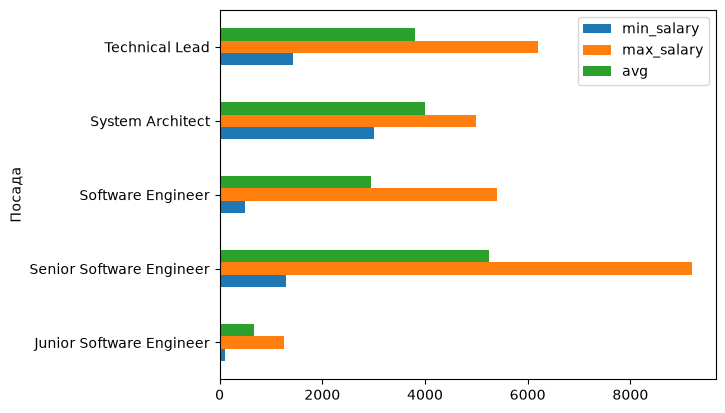

In [141]:
python_salary_by_position.plot(kind='barh')

Створіть описову статистику за допомогою методу `describe` для нового стовпчика `"avg"`.

In [136]:
python_salary_by_position['avg'].describe()

count       5.000000
mean     3337.500000
std      1700.091909
min       675.000000
25%      2950.000000
50%      3812.500000
75%      4000.000000
max      5250.000000
Name: avg, dtype: float64

Збережіть отриману таблицю в CSV-файл.


In [142]:
python_salary_by_position.to_csv('outputs/python_salary_by_position.csv', index=False)

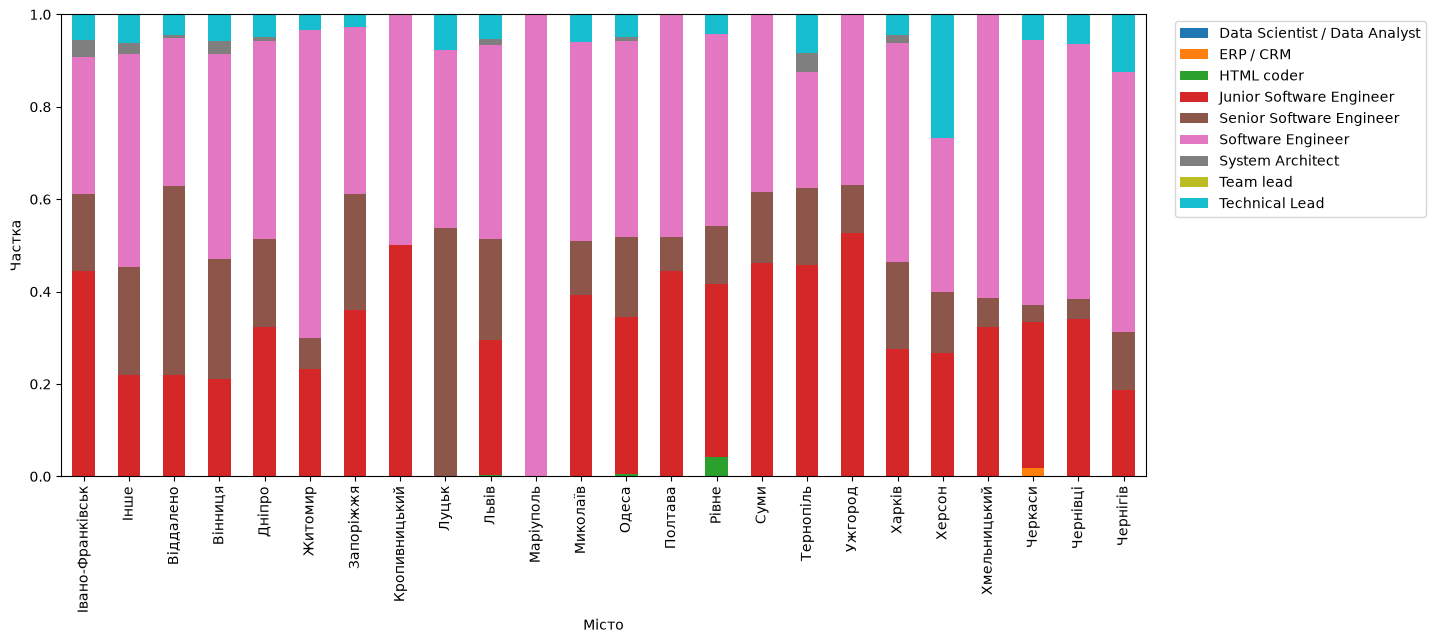

In [169]:
plot_data = df[df.Місто != 'Київ'].groupby('Місто')['Посада'].value_counts(normalize=True).unstack()
plot_data.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='tab10')
plt.ylabel('Частка')
plt.legend(bbox_to_anchor=(1.02, 1))

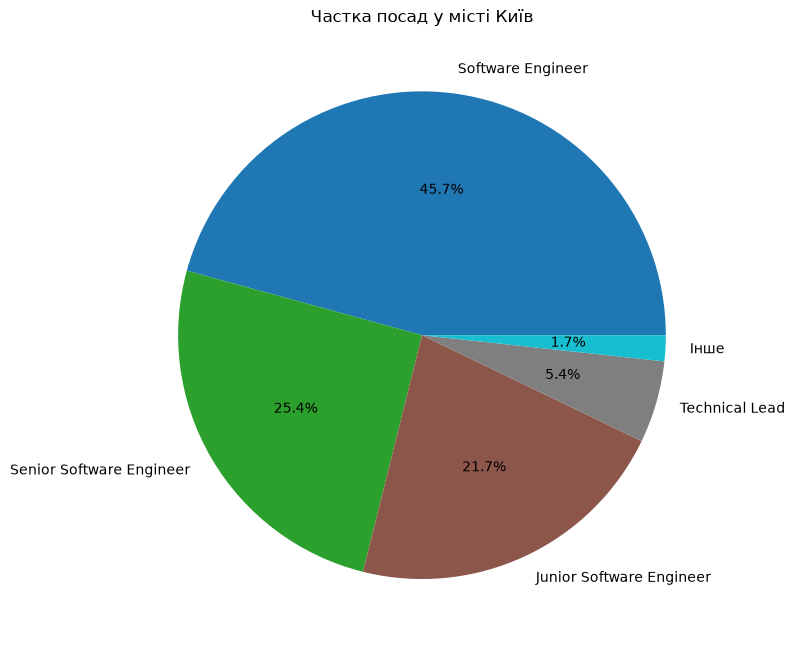

In [183]:
plot_data = df[df.Місто == 'Київ']['Посада'].value_counts(normalize=True)

threshold = 0.02
small = plot_data[plot_data < threshold].sum()
plot_data = plot_data[plot_data >= threshold]
plot_data['Інше'] = small

fig, ax = plt.subplots(figsize=(8, 8))
plot_data.plot(kind='pie', autopct='%1.1f%%', colormap='tab10', ax=ax)
ax.set_title('Частка посад у місті Київ')
plt.tight_layout()